In [1]:
#!pip install datasets pandas numpy seaborn matplotlib tensorflow scikit-learn
from datasets import load_dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from datasets import load_dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import TextVectorization, Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.models import Sequential

c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("armanc/pubmed-rct20k")
print(ds)

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 176642
    })
    validation: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29672
    })
    test: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29578
    })
})


In [3]:
df_train = pd.DataFrame(ds['train'])
df_train.head()

,abstract_id,label,text,sentence_id
0,24293578,objective,To investigate the efficacy of @ weeks of dail...,0
1,24293578,methods,A total of @ patients with primary knee OA wer...,1
2,24293578,methods,Outcome measures included pain reduction and i...,2
3,24293578,methods,Pain was assessed using the visual analog pain...,3
4,24293578,methods,Secondary outcome measures included the Wester...,4


In [4]:
df_validation = pd.DataFrame(ds['validation'])
df_validation.head()

,abstract_id,label,text,sentence_id
0,24290286,background,IgE sensitization to Aspergillus fumigatus and...,0
1,24290286,background,It is not clear whether these patients would b...,1
2,24290286,objective,We sought to determine whether a @-month cours...,2
3,24290286,methods,Asthmatic patients who were IgE sensitized to ...,3
4,24290286,methods,Primary outcomes were improvement in quality o...,4


In [5]:
df_test = pd.DataFrame(ds['test'])
df_test.head()

,abstract_id,label,text,sentence_id
0,24845963,background,This study analyzed liver function abnormaliti...,0
1,24845963,results,A post hoc analysis was conducted with the use...,1
2,24845963,results,Liver function tests ( LFTs ) were measured at...,2
3,24845963,results,Survival analyses were used to assess the asso...,3
4,24845963,results,The percentage of patients with abnormal LFTs ...,4


In [6]:
label_counts = df_train['label'].value_counts()
label_props = df_train['label'].value_counts(normalize=True) * 100
print(label_counts)
print(label_props.round(2))

label
methods        59281
results        57953
conclusions    27168
background     18402
objective      13838
Name: count, dtype: int64
label
methods        33.56
results        32.81
conclusions    15.38
background     10.42
objective       7.83
Name: proportion, dtype: float64


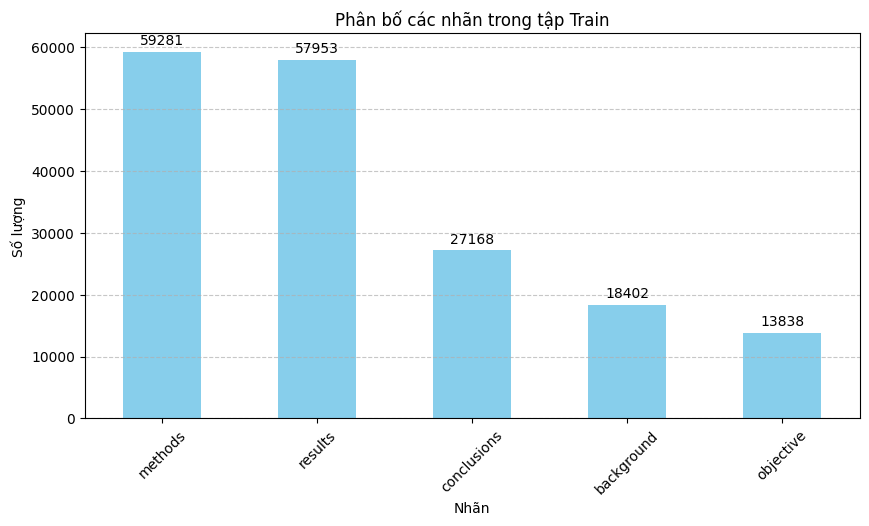

In [7]:
plt.figure(figsize=(10, 5))
ax = label_counts.plot(kind='bar', color='skyblue')
plt.title('Phân bố các nhãn trong tập Train')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.show()

In [8]:
df_train['sentence_len'] = df_train['text'].apply(lambda x: len(x.split()))
print(f"Câu ngắn nhất: {df_train['sentence_len'].min()} từ")
print(f"Câu dài nhất: {df_train['sentence_len'].max()} từ")
print(f"Độ dài trung bình: {df_train['sentence_len'].mean():.1f} từ")

Câu ngắn nhất: 1 từ
Câu dài nhất: 296 từ
Độ dài trung bình: 26.7 từ


In [9]:
#check 
one_word_sentences = df_train[df_train['sentence_len'] == 1]
print(f"Số câu chỉ có một từ: {len(one_word_sentences)}")
if 'abstract_id' in df_train.columns and 'sentence_id' in df_train.columns:
    print(one_word_sentences[['abstract_id', 'sentence_id']].head(20).values)
else: 
    print(one_word_sentences['text'].head(20).values)

Số câu chỉ có một từ: 3
[['24306695' 9]
 ['24952281' 11]
 ['25683204' 9]]


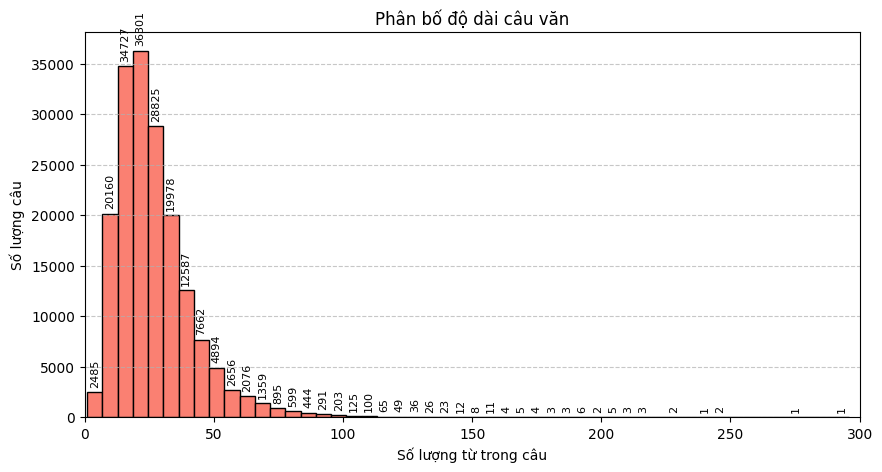

In [10]:
plt.figure(figsize=(10, 5))
counts, bins, patches = plt.hist(df_train['sentence_len'], bins=50, color='salmon', edgecolor='black')
plt.title('Phân bố độ dài câu văn')
plt.xlabel('Số lượng từ trong câu')
plt.ylabel('Số lượng câu')
plt.xlim(0, 300)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(x=patch.get_x() + patch.get_width() / 2,
                 y=patch.get_height() + 500,
                 s=int(count),
                 ha='center', va='bottom',
                 fontsize=8, rotation=90)
plt.show()

In [11]:
p90 = df_train['sentence_len'].quantile(0.90)
p95 = df_train['sentence_len'].quantile(0.95)
p99 = df_train['sentence_len'].quantile(0.99)

print(f"90% số câu trong dữ liệu dài dưới {p90} từ.")
print(f"95% số câu trong dữ liệu dài dưới {p95} từ.")
print(f"99% số câu trong dữ liệu dài dưới {p99} từ.")

90% số câu trong dữ liệu dài dưới 45.0 từ.
95% số câu trong dữ liệu dài dưới 55.0 từ.
99% số câu trong dữ liệu dài dưới 80.0 từ.


In [12]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(df_train['label'])
y_valid = label_encoder.transform(df_validation['label'])
y_test = label_encoder.transform(df_test['label'])

num_classes = len(label_encoder.classes_)
print(f"Số lượng lớp: {num_classes}")
print("Ánh xạ nhãn:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{i}: {label}")

Số lượng lớp: 5
Ánh xạ nhãn:
0: background
1: conclusions
2: methods
3: objective
4: results


In [13]:
MAX_WORDS = 20000
MAX_LEN = 55
EMBED_DIM = 128

In [14]:
text_vectorizer = TextVectorization(max_tokens=MAX_WORDS,
                                    output_sequence_length=MAX_LEN,
                                    output_mode='int')

text_vectorizer.adapt(df_train['text'])

vocab = text_vectorizer.get_vocabulary()
print(f"\n10 từ phổ biến nhất: {vocab[:10]}")


10 từ phổ biến nhất: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('of'), np.str_('in'), np.str_('to'), np.str_('with'), np.str_('a'), np.str_('were')]
